In [11]:
import pyroll.core as pr
import pyroll.wusatowski_spreading
import matplotlib.pyplot as plt
import numpy as np

print("Ready ✓")

Ready ✓


The problem we saw yesterday:

Width stayed wide → 43mm

Height reduced → 27mm

Never reached 20mm target

This happened because we squeezed in the same direction every pass — always reducing height, never controlling width.

The solution real rolling mills use:

Pass 1: Oval groove   → squeezes round bar into oval (wide and flat)

Pass 2: Round groove  → squeezes oval into round (controls width)

Pass 3: Oval groove   → squeezes round into oval again

Pass 4: Round groove  → final round product

Each pass alternates 90° — height and width take turns being reduced. This is called an oval-round pass sequence.

Before we code — one question:

Look at this groove sequence:

Round bar (60mm) → Oval → Round → Oval → Round (20mm)

If each oval-round pair reduces diameter by roughly 35%, how many oval-round pairs do you need to get from 60mm to 20mm?

Use your while loop to check — but this time reduce by 35% every 2 passes (one pair):


In [25]:
diameter = 60
reduction_per_pair = 0.35
target = 20

pairs = 0
while diameter > target:
    diameter = diameter * (1 - reduction_per_pair)
    pairs += 1
    print(f"After pair {pairs}: {diameter:.1f} mm")

print(f"\nTotal pairs needed: {pairs}")

After pair 1: 39.0 mm
After pair 2: 25.4 mm
After pair 3: 16.5 mm

Total pairs needed: 3


3 pairs = 6 passes total. ✓
So our pass sequence will look like:

Pass 1: Oval    → 60mm → ~39mm

Pass 2: Round   → ~39mm → controlled round

Pass 3: Oval    → round → flattened

Pass 4: Round   → rounder again

Pass 5: Oval    → further reduction

Pass 6: Round   → ~16mm final round product

In [13]:
sequence_test = pr.PassSequence([
    pr.RollPass(
        label="Pass 1 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=50e-3,
                depth=10e-3,
            ),
            nominal_radius=160e-3,
            rotational_frequency=1,
        ),
        gap=19.5e-3,
    ),
    pr.RollPass(
        label="Pass 2 - Round",
        roll=pr.Roll(
            groove=pr.RoundGroove(
                r1=2e-3,
                r2=19.5e-3,
                depth=19.5e-3,
            ),
            nominal_radius=160e-3,
            rotational_frequency=1,
        ),
        gap=19.5e-3,
    ),
])

sequence_test.solve(in_profile)

for pass_ in sequence_test:
    if isinstance(pass_, pr.RollPass):
        print(f"{pass_.label}: "
              f"width = {pass_.out_profile.width*1000:.1f} mm, "
              f"height = {pass_.out_profile.height*1000:.1f} mm")

Pass 1 - Oval: width = 69.2 mm, height = 39.5 mm
Pass 2 - Round: width = 41.8 mm, height = 58.5 mm


In [14]:
sequence_test2 = pr.PassSequence([
    # Pass 1 - your code above ✓
    pr.RollPass(
        label="Pass 1 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=50e-3,
                depth=10e-3,
            ),
            nominal_radius=160e-3,
            rotational_frequency=1,
        ),
        gap=19.5e-3,
    ),
    # Pass 2 - same as before
    pr.RollPass(
        label="Pass 2 - Round",
        roll=pr.Roll(
            groove=pr.RoundGroove(
                r1=2e-3,
                r2=19.5e-3,
                depth=19.5e-3,
            ),
            nominal_radius=160e-3,
            rotational_frequency=1,
        ),
        gap=19.5e-3,
    ),
    # Pass 3 - new dimensions
   pr.RollPass(
    label="Pass 3 - Oval",
    roll=pr.Roll(
        groove=pr.CircularOvalGroove(
            r1=2e-3,
            r2=60e-3,
            depth=10e-3,
        ),
        nominal_radius=160e-3,
        rotational_frequency=1,
    ),
    gap=40e-3,  # gentler reduction — 58.5mm → ~40mm
),
])

sequence_test2.solve(in_profile)

for pass_ in sequence_test2:
    if isinstance(pass_, pr.RollPass):
        print(f"{pass_.label}: "
              f"width = {pass_.out_profile.width*1000:.1f} mm, "
              f"height = {pass_.out_profile.height*1000:.1f} mm")

C:\Users\keert\anaconda3\Lib\site-packages\pyroll\core\roll_pass\hookimpls\symmetric_roll_pass.py:9: RuntimeWarning: invalid value encountered in sqrt
  return -np.sqrt(self.roll.min_radius * height_change - height_change**2 / 4)


RuntimeError: Solution of sub units failed at unit TwoRollPass 'Pass 3 - Oval'.

In [ ]:
# Check exact incoming dimensions to Pass 3
print("Pass 2 exit dimensions:")
for pass_ in sequence_test:
    if isinstance(pass_, pr.RollPass):
        print(f"{pass_.label}:")
        print(f"  width  = {pass_.out_profile.width*1000:.2f} mm")
        print(f"  height = {pass_.out_profile.height*1000:.2f} mm")
        print(f"  radius = {pass_.out_profile.equivalent_radius*1000:.2f} mm")

# Check what height_change would be
incoming_height = 58.5e-3
gap = 40e-3
height_change = incoming_height - gap
roll_radius = 160e-3

import numpy as np
contact_arc = roll_radius * height_change - height_change**2 / 4
print(f"\nDiagnostics:")
print(f"height_change = {height_change*1000:.1f} mm")
print(f"contact_arc check = {contact_arc:.6f}")
print(f"sqrt valid = {contact_arc >= 0}")

In [ ]:
import numpy as np

# Check if r2 of groove is compatible with incoming width
incoming_width = 41.77e-3
r2 = 60e-3
depth = 10e-3
gap = 40e-3

# Usable width of CircularOvalGroove = 2 * sqrt(2*r2*depth - depth^2)
usable_width = 2 * np.sqrt(2 * r2 * depth - depth**2)
print(f"Groove usable width = {usable_width*1000:.1f} mm")
print(f"Incoming width      = {incoming_width*1000:.1f} mm")
print(f"Groove wide enough  = {usable_width > incoming_width}")

# Check gap vs depth relationship  
print(f"\ngap = {gap*1000:.1f} mm")
print(f"depth = {depth*1000:.1f} mm")
print(f"gap > depth = {gap > depth}")

In [ ]:
print(hasattr(pr, 'FlatOvalGroove'))
print(hasattr(pr, 'Oval2RollGroove'))
print(hasattr(pr, 'SwedishOvalGroove'))

# Show all available groove types
grooves = [x for x in dir(pr) if 'Groove' in x]
print(grooves)

In [ ]:
sequence_test2 = pr.PassSequence([
    pr.RollPass(
        label="Pass 1 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=50e-3,
                depth=10e-3,
            ),
            nominal_radius=160e-3,
            rotational_frequency=1,
        ),
        gap=19.5e-3,
    ),
    pr.RollPass(
        label="Pass 2 - Round",
        roll=pr.Roll(
            groove=pr.RoundGroove(
                r1=2e-3,
                r2=19.5e-3,
                depth=19.5e-3,
            ),
            nominal_radius=160e-3,
            rotational_frequency=1,
        ),
        gap=19.5e-3,
    ),
    pr.RollPass(
        label="Pass 3 - Oval",
        roll=pr.Roll(
            groove=pr.FlatOvalGroove(
                r1=2e-3,
                r2=30e-3,
                depth=10e-3,
                 even_ground_width=20e-3
            ),
            nominal_radius=160e-3,
            rotational_frequency=1,
        ),
        gap=40e-3,
    ),
])

sequence_test2.solve(in_profile)

for pass_ in sequence_test2:
    if isinstance(pass_, pr.RollPass):
        print(f"{pass_.label}: "
              f"width = {pass_.out_profile.width*1000:.1f} mm, "
              f"height = {pass_.out_profile.height*1000:.1f} mm")

In [ ]:
in_profile = pr.Profile.round(
    radius=30e-3,
    temperature=1200 + 273.15,
    strain=0,
    material=["steel", "C15"],
    flow_stress=100e6,
    density=7.5e3,
    specific_heat_capacity=690,
)

sequence_test = pr.PassSequence([
    # PAIR 1
    pr.RollPass(
        label="Pass 1 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=50e-3,
                depth=10e-3,
            ),
            nominal_radius=160e-3,
            rotational_frequency=1,
        ),
        gap=19.5e-3,  # targets ~39mm height
    ),
    pr.RollPass(
        label="Pass 2 - Round",
        roll=pr.Roll(
            groove=pr.RoundGroove(
                r1=2e-3,
                r2=19.5e-3,  # matches exit of Pass 1
                depth=19.5e-3,
            ),
            nominal_radius=160e-3,
            rotational_frequency=1,
        ),
        gap=19.5e-3,
    ),
   pr.RollPass(
        label="Pass 3 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=25.4e-3/2,  # matches exit of Pass 1
                depth=8e-3,
            ),
            nominal_radius=160e-3,
            rotational_frequency=1,
         
        ),
        gap=25.4e-3/2,
    ),
   pr.RollPass(
        label="Pass 4 - Round",
        roll=pr.Roll(
            groove=pr.RoundGroove(
                r1=2e-3,
                r2=25.4e-3/2,  # matches exit of Pass 1
                depth=25.4e-3/2,
            ),
            nominal_radius=160e-3,
            rotational_frequency=1,
        ),
        gap=25.4e-3/2,
    ),
     pr.RollPass(
        label="Pass 5 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=16.5e-3/2,  # matches exit of Pass 1
                depth=5e-3,
            ),
            nominal_radius=160e-3,
            rotational_frequency=1,
           
        ),
        gap=16.5e-3/2,
    ),
      pr.RollPass(
        label="Pass 6 - Round",
        roll=pr.Roll(
            groove=pr.RoundGroove(
                r1=2e-3,
                r2=16.5e-3/2,  # matches exit of Pass 1
                depth=16.5e-3/2,
            ),
            nominal_radius=160e-3,
            rotational_frequency=1,
        ),
        gap=16.5e-3/2,
    ),
])

# Run just passes 1 and 2 first
sequence_test = pr.PassSequence([
    # paste Pass 1 and Pass 2 only here
])

sequence_test.solve(in_profile)

for pass_ in sequence_test:
    if isinstance(pass_, pr.RollPass):
        print(f"{pass_.label}: "
              f"width = {pass_.out_profile.width*1000:.1f} mm, "
              f"height = {pass_.out_profile.height*1000:.1f} mm")

Key thing to notice:

RoundGroove only needs r1 and r2 — no depth parameter. 

The round groove is symmetric so depth is derived from radius.

In [ ]:
import pyroll.core as pr
import pyroll.wusatowski_spreading

in_profile = pr.Profile.round(
    radius=30e-3,
    temperature=1200 + 273.15,
    strain=0,
    material=["steel", "C15"],
    flow_stress=100e6,
    density=7.5e3,
    specific_heat_capacity=690,
)

sequence = pr.PassSequence([
    pr.RollPass(
        label="R1 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=60.5e-3,
                depth=15.5e-3
            ),
            nominal_radius=155e-3,
        ),
        gap=6.5e-3,
    ),
    pr.Transport(label="R1->R2", length=1e3),
    pr.RollPass(
        label="R2 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(
                r1=2e-3,
                r2=23.75e-3,
                depth=17.5e-3,
                flank_angle=30
            ),
            nominal_radius=155e-3,
        ),
        gap=6.5e-3,
    ),
    pr.Transport(label="R2->R3", length=1e3),
    pr.RollPass(
        label="R3 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=39.28e-3,
                depth=12.25e-3
            ),
            nominal_radius=155e-3,
        ),
        gap=5.5e-3,
    ),
    pr.Transport(label="R3->R4", length=1e3),
    pr.RollPass(
        label="R4 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(
                r1=2e-3,
                r2=18e-3,
                depth=15.25e-3,
                flank_angle=30
            ),
            nominal_radius=155e-3,
        ),
        gap=5.5e-3,
    ),
])

sequence.solve(in_profile)

for unit in sequence:
    if isinstance(unit, pr.RollPass):
        print(f"{unit.label}: "
              f"width = {unit.out_profile.width*1000:.1f} mm, "
              f"height = {unit.out_profile.height*1000:.1f} mm")

In [ ]:
import traceback

try:
    sequence.solve(in_profile)
except Exception as e:
    # Get the root cause, not just the last error
    cause = e.__cause__
    while cause.__cause__:
        cause = cause.__cause__
    print("ROOT CAUSE:", type(cause).__name__)
    print("MESSAGE:", str(cause))

In [ ]:
sequence = pr.PassSequence([
    pr.RollPass(
        label="R1 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=60.5e-3,
                depth=15.5e-3
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,  # ← add this
        ),
        gap=6.5e-3,
    ),
    pr.Transport(label="R1->R2", length=1e3),
    pr.RollPass(
        label="R2 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(
                r1=2e-3,
                r2=23.75e-3,
                depth=17.5e-3,
                flank_angle=30
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,  # ← add this
        ),
        gap=6.5e-3,
    ),
    pr.Transport(label="R2->R3", length=1e3),
    pr.RollPass(
        label="R3 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=39.28e-3,
                depth=12.25e-3
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,  # ← add this
        ),
        gap=5.5e-3,
    ),
    pr.Transport(label="R3->R4", length=1e3),
    pr.RollPass(
        label="R4 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(
                r1=2e-3,
                r2=18e-3,
                depth=15.25e-3,
                flank_angle=30
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,  # ← add this
        ),
        gap=5.5e-3,
    ),
])

sequence.solve(in_profile)

for unit in sequence:
    if isinstance(unit, pr.RollPass):
        print(f"{unit.label}: "
              f"width = {unit.out_profile.width*1000:.1f} mm, "
              f"height = {unit.out_profile.height*1000:.1f} mm")

In [ ]:
import matplotlib.pyplot as plt

passes = [u.label for u in sequence if isinstance(u, pr.RollPass)]
widths = [u.out_profile.width*1000 for u in sequence if isinstance(u, pr.RollPass)]
heights = [u.out_profile.height*1000 for u in sequence if isinstance(u, pr.RollPass)]

plt.figure(figsize=(10,5))
plt.plot(passes, widths, 'bo-', label='Width')
plt.plot(passes, heights, 'rs-', label='Height')
plt.axhline(y=20, color='green', linestyle='--', label='Target 20mm')
plt.ylabel('Dimension (mm)')
plt.title('Oval-Round Pass Sequence — Width vs Height')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Also print the width/height ratio - closer to 1.0 = rounder profile
print("\nRoundness ratio (width/height) — target = 1.0:")
for u in sequence:
    if isinstance(u, pr.RollPass):
        ratio = u.out_profile.width / u.out_profile.height
        print(f"{u.label}: {ratio:.3f}")

In [ ]:
# ============================================================
# DAY 2 — Groove Geometry & Oval-Round Pass Sequences
# PyRolL Learning — TU Bergakademie Freiberg Thesis Prep
# ============================================================

# CELL 1 — Imports
import pyroll.core as pr
import pyroll.wusatowski_spreading
import matplotlib.pyplot as plt
import numpy as np

print("Imports successful ✓")
print("PyRolL version:", end=" ")
from importlib.metadata import version
print(version("pyroll-core"))

In [ ]:
# CELL 2 — Incoming Profile
# 60mm diameter round bar at 1200°C
in_profile = pr.Profile.round(
    radius=30e-3,
    temperature=1200 + 273.15,
    strain=0,
    material=["steel", "C15"],
    flow_stress=100e6,
    density=7.5e3,
    specific_heat_capacity=690,
)

print("Incoming profile:")
print(f"  Radius:      {in_profile.radius*1000:.1f} mm")
print(f"  Diameter:    {in_profile.radius*2000:.1f} mm")
print(f"  Temperature: {in_profile.temperature - 273.15:.0f} °C")

In [ ]:
# CELL 3 — Why Oval-Round? (Theory recap)
# When we squeeze from ONE direction every pass:
# → Material spreads sideways uncontrolled
# → Width grows, height reduces, but never reaches target
#
# Oval-Round alternates compression direction:
# Oval pass  → squeezes height, material spreads wide
# Round pass → squeezes width, material becomes round
# Repeat     → controlled reduction in both directions
#
# Pattern:
# Round bar → Oval (flat) → Round → Oval (flat) → Round → target
print("Theory recap printed ✓")
print()
print("Oval-Round pattern:")
print("  Pass 1 Oval:  height ↓  width ↑  → flat oval")
print("  Pass 2 Round: width  ↓  height ↑ → round profile")
print("  Pass 3 Oval:  height ↓  width ↑  → flat oval")
print("  Pass 4 Round: width  ↓  height ↑ → round profile")
print()
print("Key rule: r2 of groove must be > incoming width / 2")
print("Key rule: gap controls exit height")
print("Key rule: depth controls groove geometry")

In [16]:
# CELL 4 — 4-Pass Oval-Round Sequence
sequence = pr.PassSequence([
    pr.RollPass(
        label="R1 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=60.5e-3,   # wide groove for 60mm bar
                depth=15.5e-3
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=6.5e-3,
    ),
    pr.Transport(label="R1->R2", length=1e3),

    pr.RollPass(
        label="R2 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(
                r1=2e-3,
                r2=23.75e-3,
                depth=17.5e-3,
                flank_angle=30
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=6.5e-3,
    ),
    pr.Transport(label="R2->R3", length=1e3),

    pr.RollPass(
        label="R3 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=39.28e-3,
                depth=12.25e-3
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=5.5e-3,
    ),
    pr.Transport(label="R3->R4", length=1e3),

    pr.RollPass(
        label="R4 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(
                r1=2e-3,
                r2=18e-3,
                depth=15.25e-3,
                flank_angle=30
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=5.5e-3,
    ),
])

print("Sequence defined ✓")
print(f"Total units: {len(sequence)}")
print(f"Roll passes: {len(list(sequence.roll_passes))}")

Sequence defined ✓
Total units: 7
Roll passes: 4


In [17]:
# CELL 5 — Solve & Print Results
sequence.solve(in_profile)

print("="*55)
print(f"{'Pass':<15} {'Width (mm)':>10} {'Height (mm)':>12} {'Ratio':>8}")
print("="*55)

for unit in sequence:
    if isinstance(unit, pr.RollPass):
        w = unit.out_profile.width * 1000
        h = unit.out_profile.height * 1000
        ratio = w / h
        print(f"{unit.label:<15} {w:>10.1f} {h:>12.1f} {ratio:>8.3f}")

print("="*55)
print("Ratio = width/height — target = 1.000 (perfect round)")

Pass            Width (mm)  Height (mm)    Ratio
R1 - Oval             69.9         37.5    1.864
R2 - Round            49.7         41.5    1.197
R3 - Oval             52.0         30.0    1.734
R4 - Round            36.3         36.0    1.007
Ratio = width/height — target = 1.000 (perfect round)


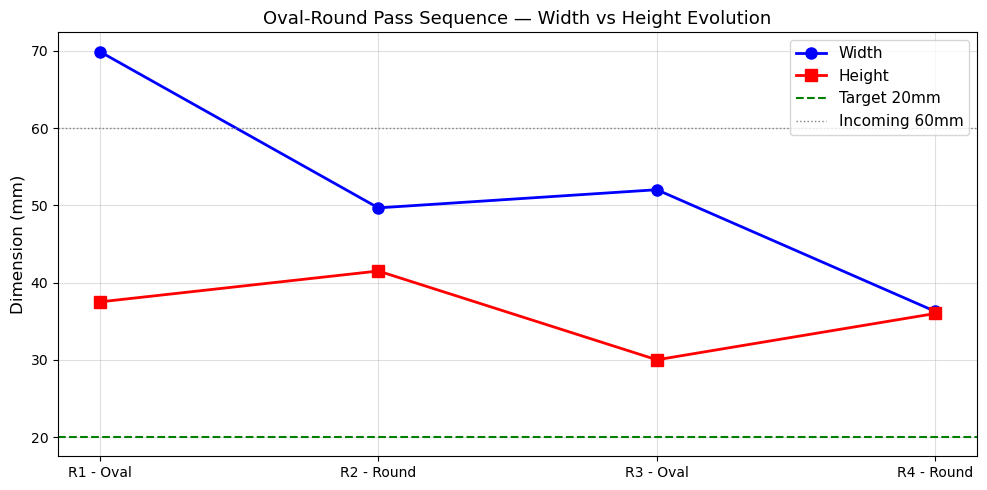

Plot saved ✓


In [15]:
# CELL 6 — Width & Height Evolution Plot
passes = [u.label for u in sequence if isinstance(u, pr.RollPass)]
widths = [u.out_profile.width*1000 for u in sequence if isinstance(u, pr.RollPass)]
heights = [u.out_profile.height*1000 for u in sequence if isinstance(u, pr.RollPass)]

plt.figure(figsize=(10, 5))
plt.plot(passes, widths, 'bo-', linewidth=2, markersize=8, label='Width')
plt.plot(passes, heights, 'rs-', linewidth=2, markersize=8, label='Height')
plt.axhline(y=20, color='green', linestyle='--', linewidth=1.5, label='Target 20mm')
plt.axhline(y=60, color='gray', linestyle=':', linewidth=1, label='Incoming 60mm')
plt.ylabel('Dimension (mm)', fontsize=12)
plt.title('Oval-Round Pass Sequence — Width vs Height Evolution', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('day02_width_height.png', dpi=150)
plt.show()
print("Plot saved ✓")

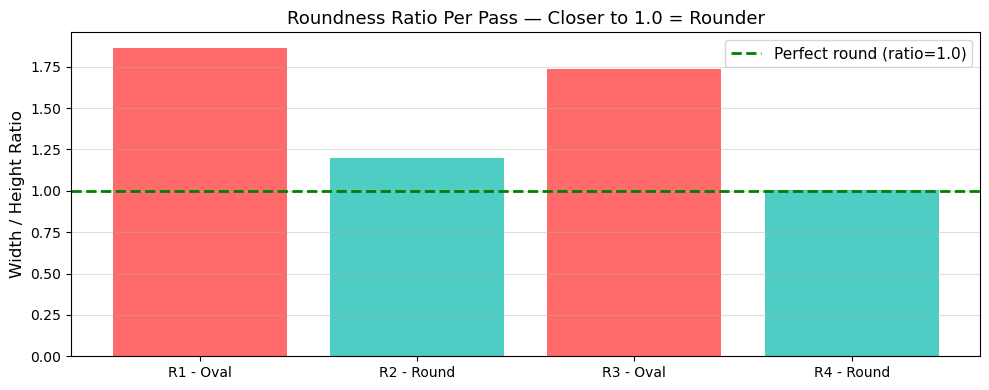


Roundness ratios:
  R1 - Oval       1.864  ██████████████████
  R2 - Round      1.197  ███████████
  R3 - Oval       1.734  █████████████████
  R4 - Round      1.007  ██████████


In [18]:
# CELL 7 — Roundness Ratio Plot
ratios = [u.out_profile.width / u.out_profile.height 
          for u in sequence if isinstance(u, pr.RollPass)]

plt.figure(figsize=(10, 4))
plt.bar(passes, ratios, color=['#FF6B6B', '#4ECDC4', '#FF6B6B', '#4ECDC4'])
plt.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Perfect round (ratio=1.0)')
plt.ylabel('Width / Height Ratio', fontsize=12)
plt.title('Roundness Ratio Per Pass — Closer to 1.0 = Rounder', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4, axis='y')
plt.tight_layout()
plt.savefig('day02_roundness.png', dpi=150)
plt.show()

print("\nRoundness ratios:")
for p, r in zip(passes, ratios):
    bar = "█" * int(r * 10)
    print(f"  {p:<15} {r:.3f}  {bar}")

In [19]:
# CELL 8 — Key Observations (run and read carefully)
print("KEY OBSERVATIONS FROM DAY 2:")
print()
print("1. ZIGZAG PATTERN:")
print("   Oval passes  → width HIGH, height LOW")
print("   Round passes → width ≈ height (nearly round)")
print()
print("2. ROUNDNESS:")
r4_ratio = list(sequence.roll_passes)[-1].out_profile.width / \
           list(sequence.roll_passes)[-1].out_profile.height
print(f"   R4 roundness ratio = {r4_ratio:.3f} (1.000 = perfect)")
print()
print("3. WE STILL HAVEN'T REACHED 20mm:")
r4_h = list(sequence.roll_passes)[-1].out_profile.height * 1000
print(f"   R4 exit height = {r4_h:.1f} mm (target = 20mm)")
print(f"   → Need more passes — covered in Day 3")
print()
print("4. TRANSPORT BETWEEN PASSES:")
print("   pr.Transport models the bar travelling between")
print("   mill stands — affects temperature cooling")
print("   → Day 3 we will track temperature evolution")
print()
print("5. GROOVE SELECTION RULES:")
print("   CircularOvalGroove → flat oval, controls height")
print("   FalseRoundGroove   → round profile, controls width")
print("   r2 must be > incoming_width / 2 (avoid overfilling)")
print("   gap sets exit height")

KEY OBSERVATIONS FROM DAY 2:

1. ZIGZAG PATTERN:
   Oval passes  → width HIGH, height LOW
   Round passes → width ≈ height (nearly round)

2. ROUNDNESS:
   R4 roundness ratio = 1.007 (1.000 = perfect)

3. WE STILL HAVEN'T REACHED 20mm:
   R4 exit height = 36.0 mm (target = 20mm)
   → Need more passes — covered in Day 3

4. TRANSPORT BETWEEN PASSES:
   pr.Transport models the bar travelling between
   mill stands — affects temperature cooling
   → Day 3 we will track temperature evolution

5. GROOVE SELECTION RULES:
   CircularOvalGroove → flat oval, controls height
   FalseRoundGroove   → round profile, controls width
   r2 must be > incoming_width / 2 (avoid overfilling)
   gap sets exit height


In [ ]:
# CELL 9 — What You Learned Today (self check)
print("DAY 2 COMPLETE ✓")
print()
print("You now understand:")
print("  ✓ Why oval-round sequences are used in rolling mills")
print("  ✓ How material alternates between flat and round")
print("  ✓ How to set groove parameters without overfilling")
print("  ✓ How to read root cause errors in PyRolL")
print("  ✓ How to use pr.Transport between passes")
print("  ✓ How to visualize pass schedule evolution")
print()
print("Tomorrow — Day 3:")
print("  → Extend to 8 passes to reach 20mm target")
print("  → Track temperature drop across transports")
print("  → Plot temperature + dimensions together")
print("  → Calculate roll force and power per pass")

In [20]:
pr.RollPass(
    label="R5 - Oval",
    roll=pr.Roll(
        groove=pr.CircularOvalGroove(
            r1=2e-3,
            r2=28e-3,    # safely > 36.3/2 = 18.15mm
            depth=8e-3,  # shallow — oval pass
        ),
        nominal_radius=155e-3,
        rotational_frequency=1,
    ),
    gap=25e-3,  # target exit height 25mm
),

# **The three rules one more time — memorise these:**
'''
r2  → always > incoming_width / 2
gap → set to your TARGET exit height
depth → oval: 5–15mm / round: ≈ r2

Now design **R6 — a round pass** after R5.

R5 will exit at roughly:
```
height ≈ 25mm
width  ≈ wider than 36mm (spread)'''

'\nr2  → always > incoming_width / 2\ngap → set to your TARGET exit height\ndepth → oval: 5–15mm / round: ≈ r2\n\nNow design **R6 — a round pass** after R5.\n\nR5 will exit at roughly:\n```\nheight ≈ 25mm\nwidth  ≈ wider than 36mm (spread)'

In [21]:
# Test R5 in isolation only
test_sequence = pr.PassSequence([
    pr.RollPass(
        label="R4 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(
                r1=2e-3,
                r2=18e-3,
                depth=15.25e-3,
                flank_angle=30
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=5.5e-3,
    ),
    pr.Transport(label="R4->R5", length=1e3),
    pr.RollPass(
        label="R5 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=28e-3,
                depth=5e-3,
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=28e-3,
    ),
])

# Get exact R4 exit profile first
test_r4 = pr.PassSequence([
    pr.RollPass(
        label="R1 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=60.5e-3,
                depth=15.5e-3
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=6.5e-3,
    ),
    pr.Transport(label="R1->R2", length=1e3),
    pr.RollPass(
        label="R2 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(
                r1=2e-3,
                r2=23.75e-3,
                depth=17.5e-3,
                flank_angle=30
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=6.5e-3,
    ),
    pr.Transport(label="R2->R3", length=1e3),
    pr.RollPass(
        label="R3 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=39.28e-3,
                depth=12.25e-3
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=5.5e-3,
    ),
    pr.Transport(label="R3->R4", length=1e3),
    pr.RollPass(
        label="R4 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(
                r1=2e-3,
                r2=18e-3,
                depth=15.25e-3,
                flank_angle=30
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=5.5e-3,
    ),
])

test_r4.solve(in_profile)

# Get exact R4 exit dimensions
r4_out = list(test_r4.roll_passes)[-1].out_profile
print(f"R4 exact exit:")
print(f"  width  = {r4_out.width*1000:.2f} mm")
print(f"  height = {r4_out.height*1000:.2f} mm")
print(f"  equivalent_radius = {r4_out.equivalent_radius*1000:.2f} mm")

# Now check what R5 needs
print(f"\nR5 needs:")
print(f"  r2 > {r4_out.width*1000/2:.2f} mm (incoming_width/2)")
print(f"  gap < {r4_out.height*1000:.2f} mm (incoming_height)")

R4 exact exit:
  width  = 36.26 mm
  height = 36.00 mm
  equivalent_radius = 18.47 mm

R5 needs:
  r2 > 18.13 mm (incoming_width/2)
  gap < 36.00 mm (incoming_height)


In [22]:
# Test R5 in isolation only
test_sequence = pr.PassSequence([
    pr.RollPass(
        label="R4 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(
                r1=2e-3,
                r2=18e-3,
                depth=15.25e-3,
                flank_angle=30
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=5.5e-3,
    ),
    pr.Transport(label="R4->R5", length=1e3),
    pr.RollPass(
        label="R5 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=28e-3,
                depth=5e-3,
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=28e-3,
    ),
])

# Get exact R4 exit profile first
test_r4 = pr.PassSequence([
    pr.RollPass(
        label="R1 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=60.5e-3,
                depth=15.5e-3
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=6.5e-3,
    ),
    pr.Transport(label="R1->R2", length=1e3),
    pr.RollPass(
        label="R2 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(
                r1=2e-3,
                r2=23.75e-3,
                depth=17.5e-3,
                flank_angle=30
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=6.5e-3,
    ),
    pr.Transport(label="R2->R3", length=1e3),
    pr.RollPass(
        label="R3 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=39.28e-3,
                depth=12.25e-3
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=5.5e-3,
    ),
    pr.Transport(label="R3->R4", length=1e3),
    pr.RollPass(
        label="R4 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(
                r1=2e-3,
                r2=18e-3,
                depth=15.25e-3,
                flank_angle=30
            ),
            nominal_radius=155e-3,
            rotational_frequency=1,
        ),
        gap=5.5e-3,
    ),
])

test_r4.solve(in_profile)

# Get exact R4 exit dimensions
r4_out = list(test_r4.roll_passes)[-1].out_profile
print(f"R4 exact exit:")
print(f"  width  = {r4_out.width*1000:.2f} mm")
print(f"  height = {r4_out.height*1000:.2f} mm")
print(f"  equivalent_radius = {r4_out.equivalent_radius*1000:.2f} mm")

# Now check what R5 needs
print(f"\nR5 needs:")
print(f"  r2 > {r4_out.width*1000/2:.2f} mm (incoming_width/2)")
print(f"  gap < {r4_out.height*1000:.2f} mm (incoming_height)")

R4 exact exit:
  width  = 36.26 mm
  height = 36.00 mm
  equivalent_radius = 18.47 mm

R5 needs:
  r2 > 18.13 mm (incoming_width/2)
  gap < 36.00 mm (incoming_height)


Pass            Width (mm)  Height (mm)    Ratio
R1 - Oval             69.9         37.5    1.864
R2 - Round            49.7         41.5    1.197
R3 - Oval             52.0         30.0    1.734
R4 - Round            36.3         36.0    1.007
R5 - Oval             36.7         32.0    1.147
R6 - Round            34.5         31.0    1.112


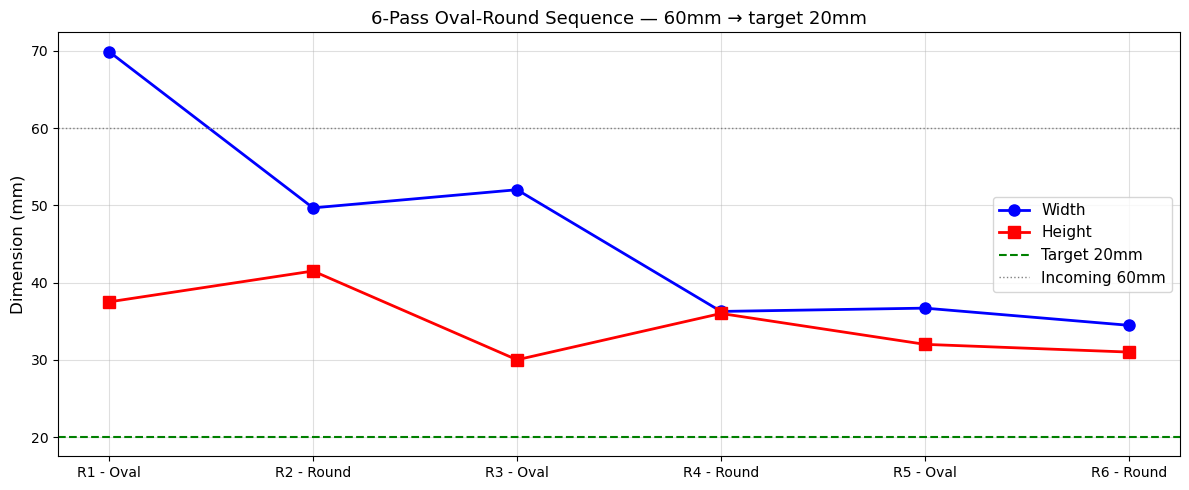

In [23]:
sequence_full = pr.PassSequence([
    pr.RollPass(
        label="R1 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(r1=2e-3, r2=60.5e-3, depth=15.5e-3),
            nominal_radius=155e-3, rotational_frequency=1,
        ),
        gap=6.5e-3,
    ),
    pr.Transport(label="R1->R2", length=1e3),
    pr.RollPass(
        label="R2 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(r1=2e-3, r2=23.75e-3, depth=17.5e-3, flank_angle=30),
            nominal_radius=155e-3, rotational_frequency=1,
        ),
        gap=6.5e-3,
    ),
    pr.Transport(label="R2->R3", length=1e3),
    pr.RollPass(
        label="R3 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(r1=2e-3, r2=39.28e-3, depth=12.25e-3),
            nominal_radius=155e-3, rotational_frequency=1,
        ),
        gap=5.5e-3,
    ),
    pr.Transport(label="R3->R4", length=1e3),
    pr.RollPass(
        label="R4 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(r1=2e-3, r2=18e-3, depth=15.25e-3, flank_angle=30),
            nominal_radius=155e-3, rotational_frequency=1,
        ),
        gap=5.5e-3,
    ),
    pr.Transport(label="R4->R5", length=1e3),
    pr.RollPass(
        label="R5 - Oval",
        roll=pr.Roll(
            groove=pr.SwedishOvalGroove(
                r1=3e-3, r2=22e-3,
                ground_width=28e-3, usable_width=45e-3, depth=6e-3
            ),
            nominal_radius=155e-3, rotational_frequency=1,
        ),
        gap=20e-3,
    ),
    pr.Transport(label="R5->R6", length=1e3),
    pr.RollPass(
        label="R6 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(
                r1=1e-3, r2=22e-3, depth=1.5e-3, flank_angle=80,
            ),
            nominal_radius=155e-3, rotational_frequency=1,
        ),
        gap=28e-3,
    ),
])

sequence_full.solve(in_profile)

print("="*55)
print(f"{'Pass':<15} {'Width (mm)':>10} {'Height (mm)':>12} {'Ratio':>8}")
print("="*55)
for unit in sequence_full:
    if isinstance(unit, pr.RollPass):
        w = unit.out_profile.width * 1000
        h = unit.out_profile.height * 1000
        print(f"{unit.label:<15} {w:>10.1f} {h:>12.1f} {w/h:>8.3f}")
print("="*55)

# Plot
import matplotlib.pyplot as plt
passes = [u.label for u in sequence_full if isinstance(u, pr.RollPass)]
widths = [u.out_profile.width*1000 for u in sequence_full if isinstance(u, pr.RollPass)]
heights = [u.out_profile.height*1000 for u in sequence_full if isinstance(u, pr.RollPass)]

plt.figure(figsize=(12, 5))
plt.plot(passes, widths, 'bo-', linewidth=2, markersize=8, label='Width')
plt.plot(passes, heights, 'rs-', linewidth=2, markersize=8, label='Height')
plt.axhline(y=20, color='green', linestyle='--', linewidth=1.5, label='Target 20mm')
plt.axhline(y=60, color='gray', linestyle=':', linewidth=1, label='Incoming 60mm')
plt.ylabel('Dimension (mm)', fontsize=12)
plt.title('6-Pass Oval-Round Sequence — 60mm → target 20mm', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()